# Oversmoothing and Over-squashing Analysis in GNNs

This notebook quantitatively analyzes the **oversmoothing phenomenon** in Graph Neural Networks (GNNs). As the number of message-passing layers increases, node representations tend to converge to a single vector, making them indistinguishable and degrading classification performance.

**We measure two metrics across GCN and GraphSAGE models of varying depths ($L \in \{2, 4, 8, 16\}$):**
1. **Normalized Dirichlet Energy**: Quantifies the smoothness/homogeneity of node embeddings. Lower energy indicates more uniform/smoothed embeddings.
   $$E(H) = \frac{\frac{1}{2} \text{Tr}(H^T L H)}{\text{Tr}(H^T H)}$$
2. **Mean Pairwise Cosine Similarity**: Measures the average alignment between all node pairs. A value close to 1.0 indicates that all node representations have converged to the same direction (oversmoothed).
   $$\text{MeanSim}(H) = \frac{1}{N^2} \sum_{i,j} \frac{h_i \cdot h_j}{\|h_i\| \|h_j\|}$$

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from main import load_dataset, build_model, set_seed
from train import train_one_epoch
from test import evaluate
from parameters import ModelParams, TrainParams, DataParams

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Setup complete. Device:', DEVICE)

Setup complete. Device: cuda


## Dirichlet Energy & Cosine Similarity Metrics

In [2]:
def compute_dirichlet_energy(x, edge_index):
    """Compute Normalized Dirichlet Energy of node representation matrix x."""
    # x: [num_nodes, hidden_channels]
    row, col = edge_index
    diff = x[row] - x[col]
    tr_x_l_x = 0.5 * torch.sum(diff * diff).item()
    tr_x_x = torch.sum(x * x).item()
    return tr_x_l_x / (tr_x_x + 1e-12)

def compute_mean_cosine_similarity(x):
    """Compute the mean pairwise cosine similarity among all nodes."""
    # x: [num_nodes, hidden_channels]
    # To avoid memory overflow on very large graphs, we sample up to 1000 nodes
    num_nodes = x.size(0)
    if num_nodes > 1000:
        indices = torch.randperm(num_nodes)[:1000]
        x_sample = x[indices]
    else:
        x_sample = x
    
    norm = torch.norm(x_sample, p=2, dim=1, keepdim=True)
    x_norm = x_sample / (norm + 1e-12)
    sim_matrix = torch.matmul(x_norm, x_norm.t())
    return torch.mean(sim_matrix).item()

## Intermediate Activation Extractor

In [3]:
@torch.no_grad()
def extract_layer_representations(model, x, edge_index):
    """Forward pass to extract intermediate layer outputs (after conv + relu)."""
    model.eval()
    reps = [x.cpu()] # input representations
    h = x
    # Iterate through all conv layers in GCN/GraphSAGE model
    for conv in model.convs:
        h = conv(h, edge_index)
        h = F.relu(h)
        reps.append(h.cpu())
    return reps

## Training and Analysis Loop

In [4]:
def analyze_oversmoothing(model_name, dataset_name='cora', depth_list=[2, 4, 8, 16], epochs=100):
    set_seed(42)
    results = []

    # Load dataset once
    data_params = DataParams(dataset_name=dataset_name, seed=42)
    ds_info = load_dataset(data_params)
    data = ds_info['data'].to(DEVICE)
    train_mask = ds_info['train_mask'].to(DEVICE)
    val_mask = ds_info['val_mask'].to(DEVICE)
    test_mask = ds_info['test_mask'].to(DEVICE)
    
    for depth in depth_list:
        print(f'Training {model_name.upper()} with depth={depth}...', end=' ', flush=True)

        model_params = ModelParams(model_name=model_name, hidden_channels=64, num_layers=depth, dropout=0.5)
        model = build_model(model_params, ds_info['num_features'], ds_info['num_classes'], 'node').to(DEVICE)
        
        optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
        
        best_val_acc = 0.0
        best_state = None
        
        for epoch in range(epochs):
            train_one_epoch(model, 'node', optimizer, DEVICE, data=data, train_mask=train_mask)
            val_acc = evaluate(model, 'node', DEVICE, data=data, mask=val_mask)['accuracy']
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_state = {k: v.cpu() for k, v in model.state_dict().items()}
                
        model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})
        test_acc = evaluate(model, 'node', DEVICE, data=data, mask=test_mask)['accuracy']
        
        # Extract layer-wise representations for this trained model
        layer_reps = extract_layer_representations(model, data.x, data.edge_index)
        
        # Compute metrics per layer
        for layer_idx, rep in enumerate(layer_reps):
            energy = compute_dirichlet_energy(rep, data.edge_index.cpu())
            cosine_sim = compute_mean_cosine_similarity(rep)
            results.append({
                'model': model_name,
                'depth': depth,
                'test_acc': test_acc,
                'val_acc': best_val_acc,
                'layer': layer_idx,
                'dirichlet_energy': energy,
                'cosine_similarity': cosine_sim
            })
        
        print(f'done. Test Acc = {test_acc:.3f}')
        
    return pd.DataFrame(results)

## Run Experiments

In [5]:
df_gcn = analyze_oversmoothing('gcn')
df_sage = analyze_oversmoothing('graphsage')

Training GCN with depth=2... 

done. Test Acc = 0.797
Training GCN with depth=4... 

done. Test Acc = 0.811
Training GCN with depth=8... 

done. Test Acc = 0.609
Training GCN with depth=16... 

done. Test Acc = 0.319
Training GRAPHSAGE with depth=2... 

done. Test Acc = 0.812
Training GRAPHSAGE with depth=4... 

done. Test Acc = 0.783
Training GRAPHSAGE with depth=8... 

done. Test Acc = 0.606
Training GRAPHSAGE with depth=16... 

done. Test Acc = 0.319


## Visualizing Oversmoothing Trends

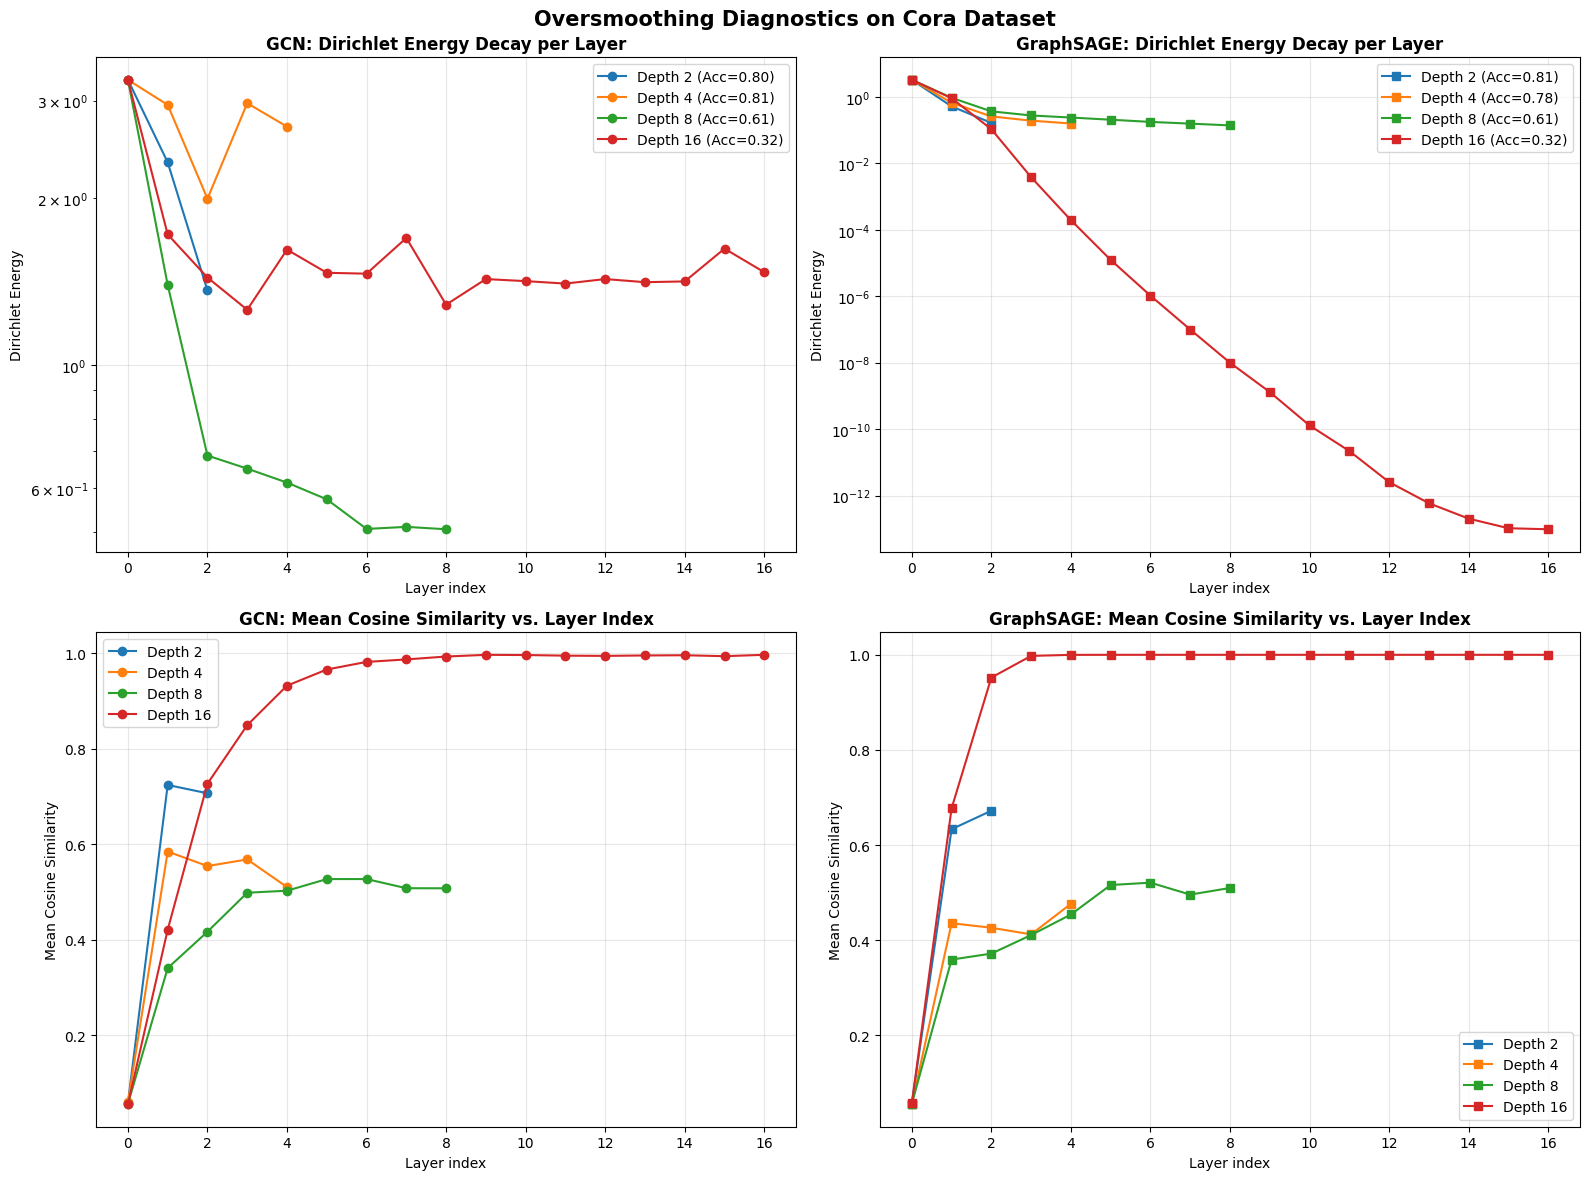

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. GCN Dirichlet Energy vs. Layer
ax = axes[0, 0]
for depth in [2, 4, 8, 16]:
    sub = df_gcn[(df_gcn['depth'] == depth)]
    ax.plot(sub['layer'], sub['dirichlet_energy'], marker='o', label=f'Depth {depth} (Acc={sub["test_acc"].iloc[0]:.2f})')
ax.set_title('GCN: Dirichlet Energy Decay per Layer', fontweight='bold')
ax.set_xlabel('Layer index')
ax.set_ylabel('Dirichlet Energy')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. GraphSAGE Dirichlet Energy vs. Layer
ax = axes[0, 1]
for depth in [2, 4, 8, 16]:
    sub = df_sage[(df_sage['depth'] == depth)]
    ax.plot(sub['layer'], sub['dirichlet_energy'], marker='s', label=f'Depth {depth} (Acc={sub["test_acc"].iloc[0]:.2f})')
ax.set_title('GraphSAGE: Dirichlet Energy Decay per Layer', fontweight='bold')
ax.set_xlabel('Layer index')
ax.set_ylabel('Dirichlet Energy')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. GCN Cosine Similarity vs. Layer
ax = axes[1, 0]
for depth in [2, 4, 8, 16]:
    sub = df_gcn[(df_gcn['depth'] == depth)]
    ax.plot(sub['layer'], sub['cosine_similarity'], marker='o', label=f'Depth {depth}')
ax.set_title('GCN: Mean Cosine Similarity vs. Layer Index', fontweight='bold')
ax.set_xlabel('Layer index')
ax.set_ylabel('Mean Cosine Similarity')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. GraphSAGE Cosine Similarity vs. Layer
ax = axes[1, 1]
for depth in [2, 4, 8, 16]:
    sub = df_sage[(df_sage['depth'] == depth)]
    ax.plot(sub['layer'], sub['cosine_similarity'], marker='s', label=f'Depth {depth}')
ax.set_title('GraphSAGE: Mean Cosine Similarity vs. Layer Index', fontweight='bold')
ax.set_xlabel('Layer index')
ax.set_ylabel('Mean Cosine Similarity')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('Oversmoothing Diagnostics on Cora Dataset', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('oversmoothing_dirichlet_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

## Summary of Test Accuracy vs. Depth

In [7]:
acc_summary = []
for depth in [2, 4, 8, 16]:
    gcn_acc = df_gcn[df_gcn['depth'] == depth]['test_acc'].iloc[0]
    sage_acc = df_sage[df_sage['depth'] == depth]['test_acc'].iloc[0]
    acc_summary.append({
        'Depth': depth,
        'GCN Accuracy': gcn_acc,
        'GraphSAGE Accuracy': sage_acc
    })

df_summary = pd.DataFrame(acc_summary)
print(df_summary.to_string(index=False))

 Depth  GCN Accuracy  GraphSAGE Accuracy
     2         0.797               0.812
     4         0.811               0.783
     8         0.609               0.606
    16         0.319               0.319
